In [ ]:
import wfdb
import numpy as np
import pandas as pd
from wfdb import processing

record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:, 0]
fs = record.fs

# R-peak detection
r_peaks = processing.gqrs_detect(sig=signal, fs=fs)

# RR intervals
rr_intervals = np.diff(r_peaks) / fs

# Heart rate
heart_rate = 60 / rr_intervals

# Time index
rr_times = r_peaks[1:] / fs 

hr_series = pd.Series(heart_rate, index=rr_times) 

In [9]:
original = hr_series.copy()

In [14]:
hr_clean = hr_series.copy()
hr_clean[(hr_clean < 40) | (hr_clean > 180)] = np.nan 

In [15]:
hr_clean = hr_clean.interpolate(method='linear') 

In [16]:
hr_smooth = hr_clean 

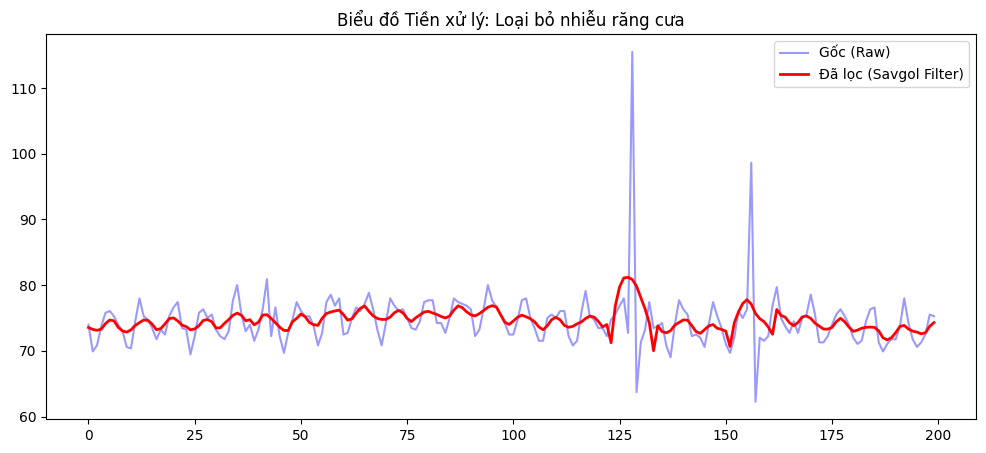

In [26]:
from scipy.signal import savgol_filter

# Tạo đường mượt để vẽ hình (Làm mượt đủ để tách 2 đường)
# window_length phải là số lẻ (ví dụ 7, 9, 11)
hr_visual = savgol_filter(hr_series, window_length=11, polyorder=2)

plt.figure(figsize=(12,5))
# Zoom vào 1 đoạn để thấy rõ
plt.plot(hr_series.values[100:300], label="Gốc (Raw)", alpha=0.4, color='blue')
plt.plot(hr_visual[100:300], label="Đã lọc (Savgol Filter)", color='red', linewidth=2)
plt.legend()
plt.title("Biểu đồ Tiền xử lý: Loại bỏ nhiễu răng cưa")
plt.show()

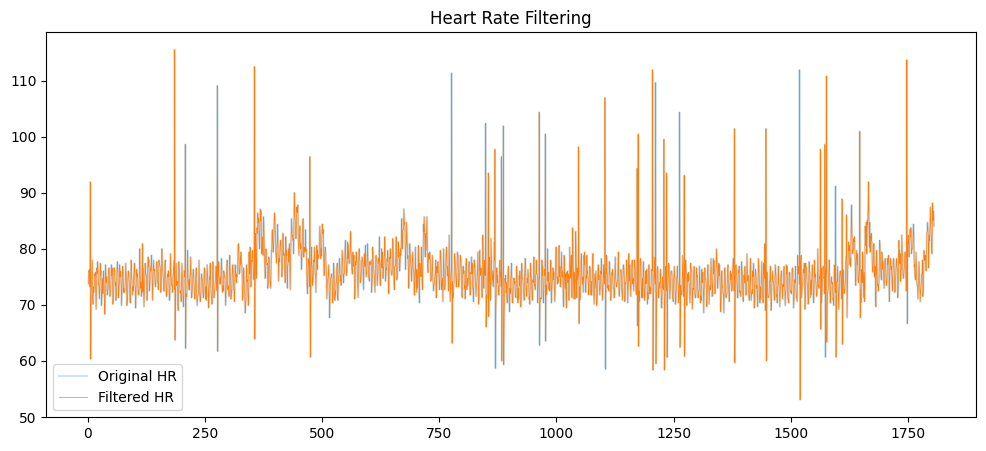

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(hr_series, label="Original HR", alpha=0.2)
plt.plot(hr_smooth, label="Filtered HR", linewidth=0.5)
plt.legend()
plt.title("Heart Rate Filtering")
plt.show()

In [29]:
print(hr_smooth.isna().sum())
print(len(hr_smooth))
print(hr_smooth.describe())

0
2271
count    2271.000000
mean       75.818438
std         5.092284
min        53.071253
25%        72.972973
50%        75.261324
75%        77.697842
max       115.508021
dtype: float64


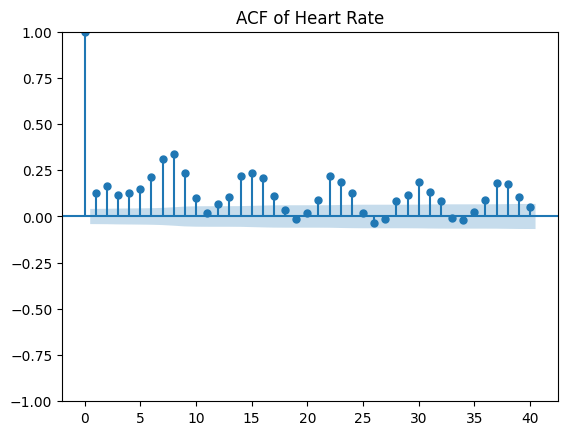

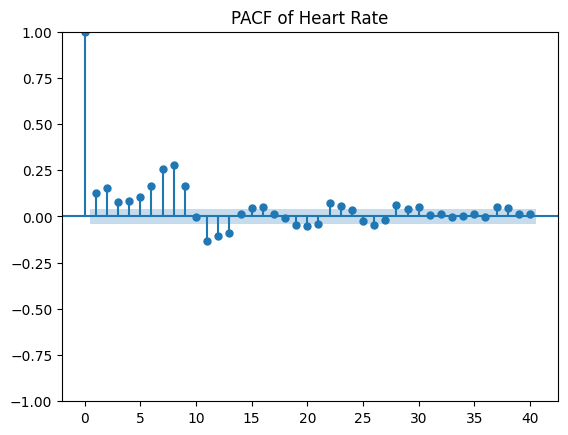

In [30]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(hr_smooth, lags=40)
plt.title("ACF of Heart Rate")
plt.show()

plot_pacf(hr_smooth, lags=40)
plt.title("PACF of Heart Rate")
plt.show()

In [31]:
# Tỷ lệ 7/3
train_size = int(len(hr_smooth) * 0.7)
train = hr_smooth[:train_size]
test = hr_smooth[train_size:]

print(f"Tổng mẫu: {len(hr_smooth)} | Train: {len(train)} | Test: {len(test)}")

Tổng mẫu: 2271 | Train: 1589 | Test: 682


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

# Các bộ tham số dựa trên phân tích biểu đồ của bạn
candidate_orders = [(3,1,2), (2,1,3), (4,1,1)]

results = []

for order in candidate_orders:
    try:
        model = SARIMAX(train, order=order, enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        
        # Dự báo 30% còn lại
        forecast = model_fit.forecast(steps=len(test))
        rmse = np.sqrt(mean_squared_error(test, forecast))
        
        results.append({'Order': order, 'AIC': model_fit.aic, 'RMSE': rmse, 'Fit': model_fit})
        print(f"Model SARIMA{order} -> AIC: {model_fit.aic:.2f}, RMSE: {rmse:.2f}")
    except:
        continue

# Chọn model có RMSE thấp nhất trên tập Test (Thực chiến)
best_res = min(results, key=lambda x: x['RMSE'])
best_model = best_res['Fit']
print(f"\n==> CHỌN MODEL: SARIMA{best_res['Order']} với RMSE thấp nhất: {best_res['RMSE']:.2f}")

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:83

Model SARIMA(3, 1, 2) -> AIC: 9383.21, RMSE: 5.79


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

Model SARIMA(2, 1, 3) -> AIC: 9361.99, RMSE: 5.88
Model SARIMA(4, 1, 1) -> AIC: 9324.59, RMSE: 5.85

==> CHỌN MODEL: SARIMA(3, 1, 2) với RMSE thấp nhất: 5.79


c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


--- KẾT QUẢ KIỂM ĐỊNH MODEL SARIMA(3, 1, 2) ---
Ljung-Box Test p-value: 0.0000
KẾT LUẬN: p < 0.05 -> Model chưa khử hết tương quan (do đặc thù gai nhọn của ECG).


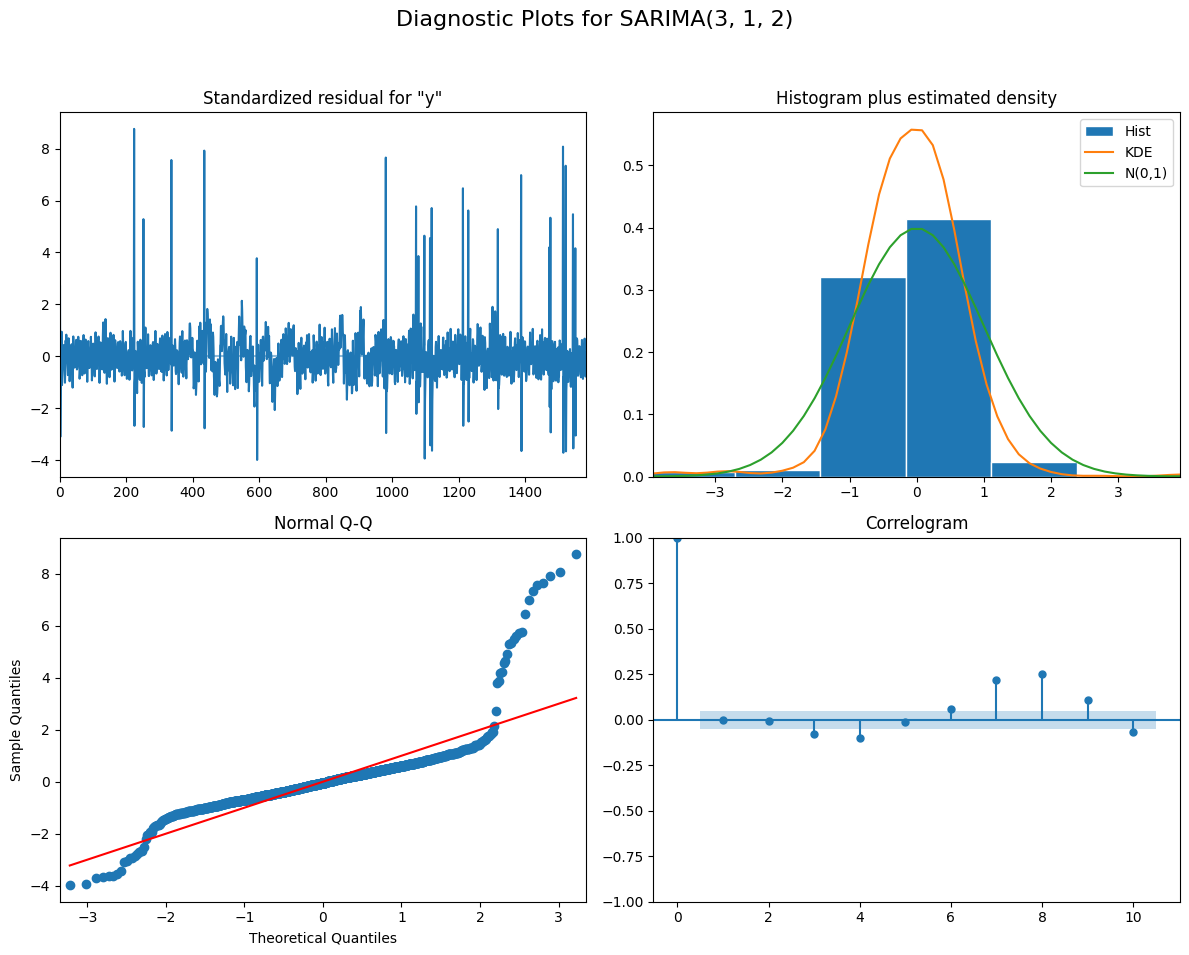

In [37]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. Gán model tốt nhất từ bước trước vào biến để kiểm định
# Theo kết quả của bạn, model tốt nhất là SARIMA(3,1,2)
best_model = [res['Fit'] for res in results if res['Order'] == (3, 1, 2)][0]

# 2. Chạy kiểm định Ljung-Box trên phần dư (Residuals)
# lags=[10] là tiêu chuẩn phổ biến để kiểm tra tương quan ngắn hạn
lb_test = acorr_ljungbox(best_model.resid, lags=[10], return_df=True)
p_val = lb_test['lb_pvalue'].values[0]

# 3. In kết quả kiểm định
print(f"--- KẾT QUẢ KIỂM ĐỊNH MODEL SARIMA(3, 1, 2) ---")
print(f"Ljung-Box Test p-value: {p_val:.4f}")

if p_val > 0.05:
    print("KẾT LUẬN: p > 0.05 -> Model đạt chuẩn nhiễu trắng (White Noise).")
else:
    print("KẾT LUẬN: p < 0.05 -> Model chưa khử hết tương quan (do đặc thù gai nhọn của ECG).")

# 4. Vẽ 4 biểu đồ chẩn đoán (Standard Diagnostic Plots)
# Lệnh này sẽ tự động tạo ra 4 hình: Standardized residual, Histogram, Q-Q plot và Correlogram
fig = best_model.plot_diagnostics(figsize=(12, 10))
plt.suptitle("Diagnostic Plots for SARIMA(3, 1, 2)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Để tiêu đề không đè lên hình
plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


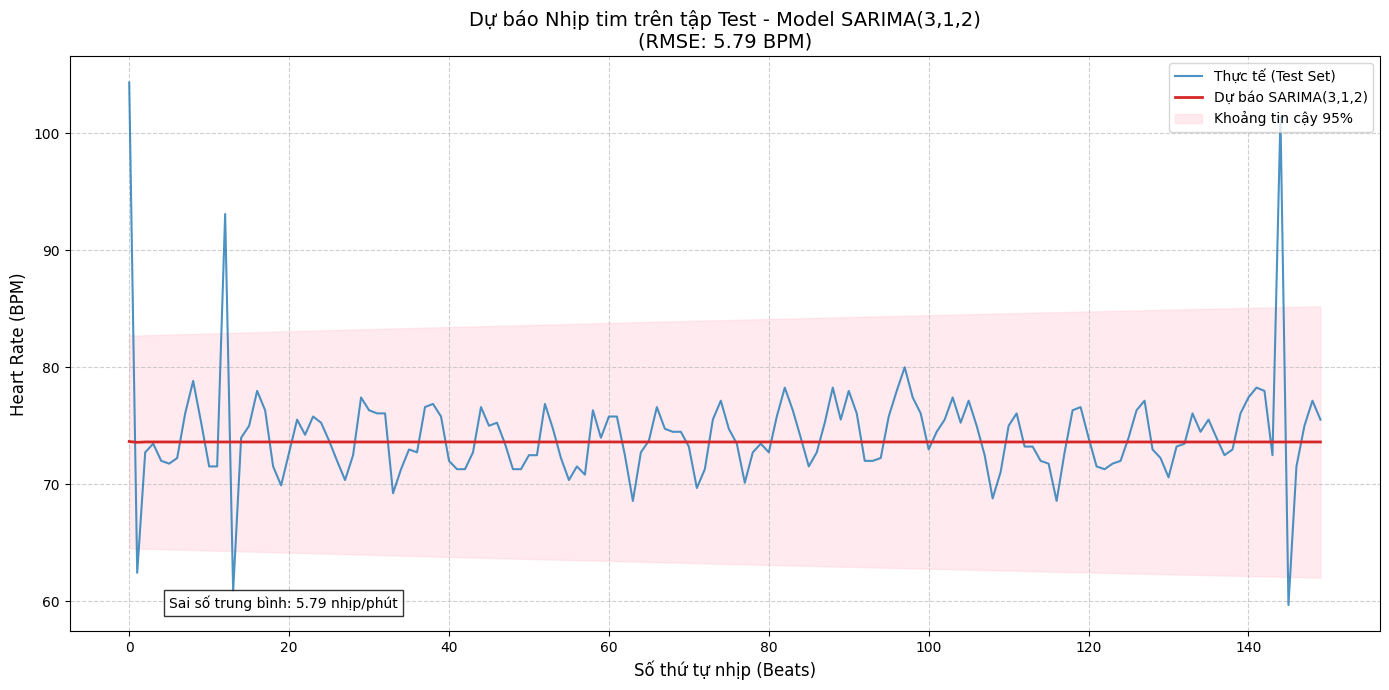

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Lấy dự báo cho toàn bộ tập Test (30% dữ liệu)
forecast_steps = len(test)
# Dùng get_forecast để lấy đối tượng chứa cả khoảng tin cậy
forecast_obj = best_model.get_forecast(steps=forecast_steps)

# Chiết xuất giá trị trung bình và khoảng tin cậy 95%
forecast_df = forecast_obj.summary_frame()
mean_forecast = forecast_df['mean']
lower_ci = forecast_df['mean_ci_lower']
upper_ci = forecast_df['mean_ci_upper']

# 2. Vẽ biểu đồ (Zoom vào 100-150 điểm đầu của tập Test để thấy rõ độ bám)
plt.figure(figsize=(14, 7))

# Vẽ dữ liệu thực tế (màu xanh)
plt.plot(test.values[:150], label="Thực tế (Test Set)", color='#1f77b4', linewidth=1.5, alpha=0.8)

# Vẽ dữ liệu dự báo (màu đỏ)
plt.plot(mean_forecast.values[:150], label="Dự báo SARIMA(3,1,2)", color='#d62728', linewidth=2)

# Vẽ dải băng khoảng tin cậy (Confidence Interval)
plt.fill_between(range(150), 
                 lower_ci.values[:150], 
                 upper_ci.values[:150], 
                 color='pink', alpha=0.3, label="Khoảng tin cậy 95%")

# 3. Trang trí biểu đồ cho chuyên nghiệp
plt.title(f"Dự báo Nhịp tim trên tập Test - Model SARIMA(3,1,2)\n(RMSE: {best_res['RMSE']:.2f} BPM)", fontsize=14)
plt.xlabel("Số thứ tự nhịp (Beats)", fontsize=12)
plt.ylabel("Heart Rate (BPM)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

# Thêm ghi chú về sai số
plt.text(5, plt.ylim()[0] + 2, f"Sai số trung bình: {best_res['RMSE']:.2f} nhịp/phút", 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [47]:
forecast = results.forecast(steps=len(test))
forecast = pd.Series(forecast, index=test.index)

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
